# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 04 — La malla real × sintético

**Esta es la pregunta del taller.** Los notebooks anteriores construyeron las piezas: el
dataset con splits purgados (01), la arquitectura downstream congelada y los baselines
clásicos (02), y seis generadores auditados contra los hechos estilizados (03). Aquí se
responde: **¿cuántos datos sintéticos ayudan, en qué régimen de escasez de datos reales, y
qué generador los produce mejor?**

### El experimento

Para cada combinación (N_real, generador, ratio, semilla):

1. Se submuestrean `N_real` ventanas del train.
2. El generador se **reentrena con esas `N_real` ventanas y solo esas**.
3. Se generan `N_synth = ratio × N_real` ventanas sintéticas.
4. Se entrena la arquitectura **congelada** del notebook 02 sobre la mezcla.
5. Se evalúa en el **test real**, intocado y siempre el mismo.

### Las cuatro reglas que hacen esto interpretable

| Regla | Por qué |
|---|---|
| **El generador se reentrena en cada celda** | Ajustarlo con las 102k ventanas y luego *simular* escasez sería fuga: los sintéticos llevarían información de datos que el escenario declara no tener, y la curva saldría optimista. |
| **Submuestreo por fechas, no por filas** | En una fecha dada todas las ventanas del panel cuentan la misma historia de mercado. Un muestreo de filas daría un N nominal muy superior al efectivo. |
| **Validación siempre real** | Si el early-stopping mirase datos sintéticos, optimizaríamos la distribución equivocada. |
| **Arquitectura e hiperparámetros congelados** | Si una celda rinde distinto, la única explicación posible son los datos. |

> **Métrica principal: `delta_r2`** — la ganancia de R² en test de cada celda frente a la
> celda de *solo real* con el mismo N. Responde literalmente al enunciado: para el mismo
> presupuesto de datos reales, ¿cuánto añade el sintético? El umbral de relevancia lo fijó
> el notebook 02: **±0,006**, la dispersión entre semillas del modelo con datos reales.
> Cualquier efecto por debajo de eso es ruido de optimización, no señal.

## 0 · Setup y configuración de la malla

**Dos tamaños de malla.** `REDUCIDA` valida el pipeline y ya cubre el régimen de escasez,
que es donde está el hallazgo; `COMPLETA` añade el extremo de datos abundantes y el ratio
10×. La diferencia de coste es de ~6×, y sale casi entera de dos celdas: `N=10.000` con
`ratio=10` entrena sobre 110.000 ventanas, tanto como el dataset completo.

**Submuestreo de la validación.** La validación real tiene 17.146 ventanas y se evalúa en
cada época de cada celda: a N pequeño ese coste fijo **domina el tiempo total** de la malla
(medido: ~45 s por celda con N=300). Como su único papel es elegir la época de la que se
conservan los pesos, 5.000 ventanas reales bastan de sobra y el coste por celda cae unas
tres veces. Es una decisión de eficiencia que no toca ninguna comparación: la validación es
idéntica en todas las celdas.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.malla import (plan_de_malla, ejecutar_malla, resumir, delta_vs_solo_real,
                       delta_pareado, umbral_ruido_por_n, SOLO_REAL)
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
print("Device:", device)

# ---- Tamaño de la malla -------------------------------------------------
MALLA = "REDUCIDA"          # "REDUCIDA" o "COMPLETA"

CONFIG_MALLA = {
    "REDUCIDA": dict(n_reales=[250, 1000, 3000], ratios=[0, 1, 3], seeds=[0, 1, 2]),
    "COMPLETA": dict(n_reales=[250, 1000, 3000, 10000], ratios=[0, 1, 3, 10], seeds=[0, 1, 2]),
}[MALLA]

GENERADORES = ["jitter", "gaussiana", "block_bootstrap", "vae", "wgan_gp", "realnvp"]
N_VAL = 5000                # submuestra de validación (real) — ver nota arriba
RUTA_CSV = cfg.out_dir / f"malla_{MALLA.lower()}.csv"

print(f"Malla {MALLA}: {CONFIG_MALLA}")
print(f"Resultados -> {RUTA_CSV}")

Device: cuda
Malla REDUCIDA: {'n_reales': [250, 1000, 3000], 'ratios': [0, 1, 3], 'seeds': [0, 1, 2]}
Resultados -> C:\Users\Javi\Documents\Codex\2026-08-31\el\work\project-updated\Taller-M5T1---Datos-Sinteticos-main\data\processed\malla_reducida.csv


In [2]:
# ---- Datos: todo lo que la malla puede tocar ----------------------------
d   = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
ref = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
meta = pd.read_parquet(cfg.out_dir / "windows_meta.parquet")
meta_train = meta[meta.split == "train"].reset_index(drop=True)

S = lambda a, m, s: ((a - std[m]) / std[s]).astype(np.float32)

# validación real submuestreada, fija para TODAS las celdas
rng_val = np.random.default_rng(cfg.seed)
iv = rng_val.choice(len(d["X_val"]), min(N_VAL, len(d["X_val"])), replace=False)

CONTEXTO = dict(
    Xs_train=S(d["X_train"], "x_mu", "x_sd"), ys_train=S(d["y_train"], "y_mu", "y_sd"),
    meta_train=meta_train,
    Xs_val=S(d["X_val"], "x_mu", "x_sd")[iv], ys_val=S(d["y_val"], "y_mu", "y_sd")[iv],
    Xs_test=S(d["X_test"], "x_mu", "x_sd"), y_test_fisico=d["y_test"],
    std=std, ref=ref, device=device,
)

print(f"Arquitectura congelada: {ref['arch']} {ref['arch_kwargs']}")
print(f"Referencia con datos reales completos: R² test = "
      f"{np.mean([v['test_r2'] for v in ref['metricas_seeds'].values()]):.4f}")
print(f"train {meta_train.shape[0]:,} ventanas / {meta_train.date_t.nunique():,} fechas | "
      f"val {len(iv):,} (submuestra) | test {len(d['X_test']):,}")

Arquitectura congelada: cnn {'channels': [32, 64, 128, 256], 'kernel': 3, 'fc': 128, 'dropout': 0.1}
Referencia con datos reales completos: R² test = 0.4646
train 102,406 ventanas / 2,372 fechas | val 5,000 (submuestra) | test 24,613


## 1 · Ejecución de la malla

El plan se ordena de **coste creciente**: si la ejecución se interrumpe, lo ya calculado es
el régimen de escasez, que es el que más importa. Cada celda se escribe al CSV en cuanto
termina, así que **relanzar esta celda reanuda donde se quedó** sin recalcular nada.

In [3]:
plan = plan_de_malla(generadores=GENERADORES, **CONFIG_MALLA)
print(f"{len(plan)} celdas en el plan "
      f"({len(CONFIG_MALLA['n_reales'])} niveles de N × "
      f"{len(CONFIG_MALLA['ratios'])} ratios × {len(GENERADORES)} generadores × "
      f"{len(CONFIG_MALLA['seeds'])} semillas)")

117 celdas en el plan (3 niveles de N × 3 ratios × 6 generadores × 3 semillas)


In [4]:
t0 = time.time()
df = ejecutar_malla(plan, RUTA_CSV, **CONTEXTO)
print(f"\nMalla terminada en {(time.time() - t0)/60:.1f} min | {len(df)} celdas en el CSV")

Malla: 117 celdas | ya hechas: 0 | pendientes: 117


[  1/117] N=   250 ninguno          synth=     0 s=0 -> R² 0.2821 (2s) | ETA 5 min


[  2/117] N=   250 ninguno          synth=     0 s=1 -> R² 0.1972 (1s) | ETA 3 min


[  3/117] N=   250 ninguno          synth=     0 s=2 -> R² 0.2246 (1s) | ETA 2 min


[  4/117] N=   250 jitter           synth=   250 s=0 -> R² 0.2637 (1s) | ETA 2 min


...

[113/117] N=  3000 wgan_gp          synth=  9000 s=1 -> R² 0.3418 (8s) | ETA 0 min


[114/117] N=  3000 wgan_gp          synth=  9000 s=2 -> R² 0.1766 (8s) | ETA 0 min


[115/117] N=  3000 realnvp          synth=  9000 s=0 -> R² 0.3659 (6s) | ETA 0 min


[116/117] N=  3000 realnvp          synth=  9000 s=1 -> R² 0.4138 (6s) | ETA 0 min


[117/117] N=  3000 realnvp          synth=  9000 s=2 -> R² 0.3878 (6s) | ETA 0 min

Malla terminada en 4.4 min | 117 celdas en el CSV


## 2 · Resultados

### 2.1 Tabla resumen

In [5]:
resumen = resumir(df)
delta = delta_vs_solo_real(resumen)

# referencia de cada N: cuánto rinde el modelo con SOLO datos reales
print("Referencia — solo datos reales:")
display(resumen[resumen.generador == SOLO_REAL][["n_real", "test_r2_media", "test_r2_sd"]].round(4))

# tabla principal: ganancia frente a esa referencia
tabla = delta.pivot_table(index=["n_real", "generador"], columns="ratio", values="delta_r2")
tabla.round(4)

Referencia — solo datos reales:


,n_real,test_r2_media,test_r2_sd
6,250,0.2346,0.0433
19,1000,0.2557,0.0346
32,3000,0.3491,0.0263


ratio                      1.0     3.0
n_real generador                      
250    block_bootstrap -0.0239 -0.0711
       gaussiana       -0.0280 -0.0526
       jitter          -0.0042 -0.0067
       realnvp         -0.0130 -0.0255
       vae             -0.0083 -0.0402
       wgan_gp         -0.2053 -0.3092
1000   block_bootstrap  0.0141  0.0200
       gaussiana       -0.0293 -0.0360
       jitter           0.0566  0.0871
       realnvp          0.0777  0.0781
       vae             -0.0009  0.0113
       wgan_gp          0.0157  0.0630
3000   block_bootstrap  0.0078 -0.0044
       gaussiana       -0.0706 -0.1007
       jitter           0.0210  0.0274
       realnvp          0.0407  0.0401
       vae             -0.0273 -0.0394
       wgan_gp         -0.0402 -0.0821

### 2.1.b Análisis pareado: la comparación que sí es válida

**Corrección metodológica importante.** El notebook 02 fijó un umbral de relevancia de
±0,006 midiendo la dispersión entre semillas del modelo entrenado con las **102.406
ventanas reales completas**. Ese umbral **no vale aquí**: en régimen de escasez la
dispersión entre semillas es de 5 a 11 veces mayor, porque cada semilla sortea un
submuestreo distinto de datos reales y eso mueve el R² mucho más que cualquier efecto del
sintético.

La solución no es subir el umbral, sino **parear**. La semilla determina qué ventanas
reales "existen" en el escenario, así que comparamos cada celda contra la celda de
solo-real **de su misma semilla**: la varianza del submuestreo se cancela y queda solo el
efecto del dato sintético. Con 3 semillas exigimos |t| ≥ 2,5 para hablar de efecto; por
debajo, la celda se declara **no concluyente** en lugar de inventar una conclusión.

In [6]:
print("Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):")
u = umbral_ruido_por_n(df)
display(pd.DataFrame({"sd_entre_semillas": u.round(4),
                      "veces el umbral del nb02 (0,006)": (u / 0.006).round(0)}))

par = delta_pareado(df)
print("\nΔ R² pareado por semilla — solo las celdas con veredicto:")
concluyentes = par[par.veredicto != "no concluyente"].sort_values("t")
display(concluyentes[["n_real", "generador", "ratio", "delta_medio", "ee", "t", "veredicto"]].round(4))
print(f"\n{len(par)} celdas: {(par.veredicto=='mejora').sum()} mejoran, "
      f"{(par.veredicto=='empeora').sum()} empeoran, "
      f"{(par.veredicto=='no concluyente').sum()} no concluyentes")

Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):


,sd_entre_semillas,"veces el umbral del nb02 (0,006)"
n_real,,
250,0.0433,7.0
1000,0.0346,6.0
3000,0.0263,4.0



Δ R² pareado por semilla — solo las celdas con veredicto:


,n_real,generador,ratio,delta_medio,ee,t,veredicto
27,3000,gaussiana,3.0,-0.1007,0.0283,-3.5606,empeora
1,250,block_bootstrap,3.0,-0.0711,0.0212,-3.3541,empeora
9,250,vae,3.0,-0.0402,0.0128,-3.1496,empeora
34,3000,wgan_gp,1.0,-0.0402,0.0132,-3.0536,empeora
0,250,block_bootstrap,1.0,-0.0239,0.0084,-2.8436,empeora
14,1000,gaussiana,1.0,-0.0293,0.0113,-2.6041,empeora
26,3000,gaussiana,1.0,-0.0706,0.0273,-2.5916,empeora
3,250,gaussiana,3.0,-0.0526,0.0205,-2.5611,empeora
24,3000,block_bootstrap,1.0,0.0078,0.0026,3.0291,mejora
17,1000,jitter,3.0,0.0871,0.0278,3.1284,mejora



36 celdas: 7 mejoran, 8 empeoran, 21 no concluyentes


### 2.2 La figura del taller: ganancia frente a proporción de sintéticos

Un panel por nivel de escasez. La banda gris es el **umbral de relevancia** (±0,006, la
dispersión entre semillas del notebook 02): cualquier curva dentro de esa banda es ruido,
no efecto.

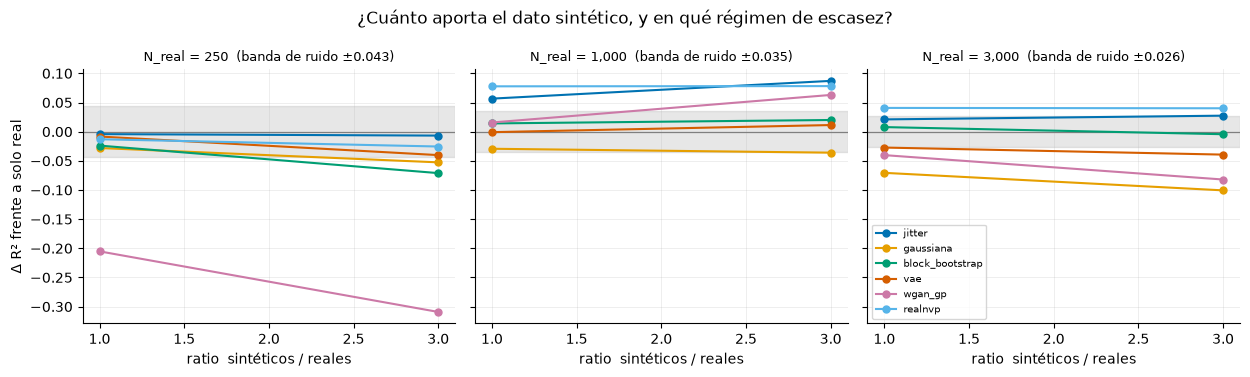

In [7]:
n_paneles = len(CONFIG_MALLA["n_reales"])
fig, axes = plt.subplots(1, n_paneles, figsize=(4.2 * n_paneles, 3.8), sharey=True)
axes = np.atleast_1d(axes)
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
# La banda es la dispersión entre semillas del solo-real EN CADA N (ver §2.1.b),
# no el ±0,006 del notebook 02, que solo vale con las 102k ventanas completas.
UMBRAL_POR_N = umbral_ruido_por_n(df)

for ax, n in zip(axes, CONFIG_MALLA["n_reales"]):
    sub = delta[delta.n_real == n]
    u = UMBRAL_POR_N[n]
    ax.axhspan(-u, u, color=PALETTE["grey"], alpha=0.18, zorder=0)
    ax.axhline(0, color=PALETTE["grey"], lw=0.9)
    for col, g in zip(colores, GENERADORES):
        s = sub[sub.generador == g].sort_values("ratio")
        if len(s):
            ax.plot(s.ratio, s.delta_r2, "o-", color=col, lw=1.5, ms=5, label=g)
    ax.set_title(f"N_real = {n:,}  (banda de ruido ±{u:.3f})", fontsize=9)
    ax.set_xlabel("ratio  sintéticos / reales")
    _style(ax)
axes[0].set_ylabel("Δ R² frente a solo real")
axes[-1].legend(fontsize=7, loc="best")
fig.suptitle("¿Cuánto aporta el dato sintético, y en qué régimen de escasez?")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "14_delta_r2_por_escasez.png", dpi=120, bbox_inches="tight")

### 2.3 Curvas de aprendizaje: R² frente a datos reales disponibles

La lectura complementaria — y la que reproduce la forma de la gráfica que el profesor
mostró en clase. La línea negra discontinua es el techo: el modelo entrenado con las
**102.406 ventanas reales completas** (notebook 02).

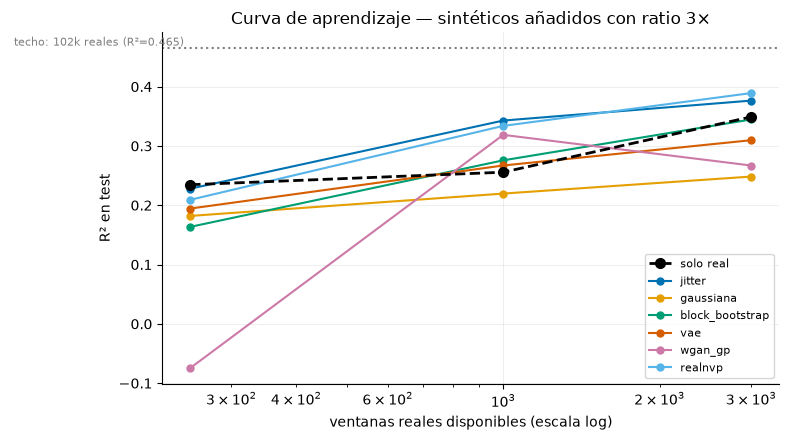

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
techo = np.mean([v["test_r2"] for v in ref["metricas_seeds"].values()])

base = resumen[resumen.generador == SOLO_REAL].sort_values("n_real")
ax.plot(base.n_real, base.test_r2_media, "o--", color="black", lw=2, ms=7,
        label="solo real", zorder=5)

RATIO_FOCO = 3 if 3 in CONFIG_MALLA["ratios"] else max(CONFIG_MALLA["ratios"])
for col, g in zip(colores, GENERADORES):
    s = resumen[(resumen.generador == g) & (resumen.ratio == RATIO_FOCO)].sort_values("n_real")
    if len(s):
        ax.plot(s.n_real, s.test_r2_media, "o-", color=col, lw=1.5, ms=5, label=g)

ax.axhline(techo, color=PALETTE["grey"], ls=":", lw=1.5)
ax.text(ax.get_xlim()[0], techo, f" techo: 102k reales (R²={techo:.3f})",
        va="bottom", fontsize=8, color=PALETTE["grey"])
ax.set_xscale("log")
ax.set_xlabel("ventanas reales disponibles (escala log)")
ax.set_ylabel("R² en test")
ax.set_title(f"Curva de aprendizaje — sintéticos añadidos con ratio {RATIO_FOCO}×")
ax.legend(fontsize=8)
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "15_curva_aprendizaje.png", dpi=120, bbox_inches="tight")

### 2.4 ¿Predice la auditoría del notebook 03 el efecto downstream?

La pregunta que cierra el círculo del taller. En el notebook 03 medimos cada generador **sin
mirar el modelo downstream**, en dos ejes: **fidelidad** (discriminative AUC, curtosis,
clustering, distancias marginales y de dependencia) y **utilidad** (el ratio TSTR/TRTR, que
entrena un modelo *solo* con datos sintéticos). Si esas métricas anticipan la ganancia real
de la malla, se puede elegir generador midiendo el sintético, sin barrer una malla entera.

> **Los números se leen del CSV que el notebook 03 persiste**, no de una tabla copiada a
> mano. Es una precaución con historia: la malla **reentrena** cada generador en cada celda,
> así que si los hiperparámetros del 03 y los de `malla.construir_generador` se desviaran, una
> tabla escrita a mano seguiría mostrando las cifras viejas y la correlación de esta sección
> compararía dos cosas distintas sin avisar.

Se cruza contra el **delta pareado** (§2.1.b) y se calcula la correlación de rangos de
Spearman por nivel de escasez, porque el resultado depende críticamente del régimen. Ojo con
los **signos**: en `discriminative_auc`, las distancias (`w1_*`, `err_*`) menos es mejor, así
que una correlación **negativa** significa que la métrica predice bien; en `curtosis_x`,
`acf_abs_lag1` y `ratio_tstr_trtr` es al revés.

In [9]:
# Auditoría del notebook 03, leída del CSV que ese notebook persiste en su §6.
RUTA_AUD, RUTA_TSTR = cfg.out_dir / "auditoria_nb03.csv", cfg.out_dir / "tstr_nb03_resumen.csv"
if not RUTA_AUD.exists():
    raise FileNotFoundError(f"Falta {RUTA_AUD.name}: ejecuta antes el notebook 03, "
                            "que lo genera en su sección de persistencia.")

AUDITORIA_NB03 = pd.read_csv(RUTA_AUD, index_col=0).rename_axis("generador").reset_index()
if RUTA_TSTR.exists():   # la utilidad TSTR es también una métrica del 03
    AUDITORIA_NB03 = AUDITORIA_NB03.merge(
        pd.read_csv(RUTA_TSTR).rename(columns={"brazo": "generador"})[
            ["generador", "ratio_tstr_trtr"]], on="generador", how="left")

# Ordenadas por eje: fidelidad global, forma, dependencia y utilidad.
METRICAS = ["discriminative_auc", "w1_x_col_media", "curtosis_x", "acf_abs_lag1",
            "err_corr_xx_spearman", "err_corr_xx_pearson", "err_corr_xy", "ratio_tstr_trtr"]
METRICAS = [m for m in METRICAS if m in AUDITORIA_NB03]
print(f"Auditoría del nb03: {len(AUDITORIA_NB03)} generadores × {len(METRICAS)} métricas")

filas = []
for n in list(CONFIG_MALLA["n_reales"]) + ["todos"]:
    sub = par if n == "todos" else par[par.n_real == n]
    gan = sub.groupby("generador")["delta_medio"].mean().rename("ganancia").reset_index()
    c = AUDITORIA_NB03.merge(gan, on="generador")
    filas.append(pd.Series(c[METRICAS].corrwith(c["ganancia"], method="spearman"), name=n))
corr = pd.DataFrame(filas)
corr.index.name = "N_real"

print("\nCorrelación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:")
display(corr.round(2))

# El mejor predictor, en valor absoluto y sobre todos los regímenes a la vez
mejor = corr.loc["todos"].abs().idxmax()
print(f"Mejor predictor sobre el conjunto de la malla: {mejor} "
      f"(Spearman {corr.loc['todos', mejor]:+.2f})")

n_ref = CONFIG_MALLA["n_reales"][1] if len(CONFIG_MALLA["n_reales"]) > 1 else CONFIG_MALLA["n_reales"][0]
orden = (par[par.n_real == n_ref].groupby("generador")["delta_medio"].mean()
         .sort_values(ascending=False))
print(f"\nOrden de mérito downstream con N_real = {n_ref}:")
print("  " + "  >  ".join(orden.index))
print("Orden por curtosis en el nb03 (colas más realistas primero):")
print("  " + "  >  ".join(AUDITORIA_NB03.sort_values("curtosis_x", ascending=False).generador))
if "ratio_tstr_trtr" in AUDITORIA_NB03:
    print("Orden por utilidad TSTR en el nb03 (más información conservada primero):")
    print("  " + "  >  ".join(
        AUDITORIA_NB03.sort_values("ratio_tstr_trtr", ascending=False).generador))
print("\n(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)")

Auditoría del nb03: 6 generadores × 8 métricas

Correlación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:


,discriminative_auc,w1_x_col_media,curtosis_x,acf_abs_lag1,err_corr_xx_spearman,err_corr_xx_pearson,err_corr_xy,ratio_tstr_trtr
N_real,,,,,,,,
250,-0.54,-0.37,0.14,0.43,-0.83,-0.43,-0.60,0.71
1000,-0.89,-0.71,0.60,0.31,-0.71,-0.03,0.09,0.77
3000,-0.89,-0.77,0.71,0.71,-0.89,0.14,0.09,0.94
todos,-0.77,-0.66,0.60,0.77,-0.83,-0.03,-0.14,0.89


Mejor predictor sobre el conjunto de la malla: ratio_tstr_trtr (Spearman +0.89)

Orden de mérito downstream con N_real = 1000:
  realnvp  >  jitter  >  wgan_gp  >  block_bootstrap  >  vae  >  gaussiana
Orden por curtosis en el nb03 (colas más realistas primero):
  block_bootstrap  >  jitter  >  realnvp  >  wgan_gp  >  vae  >  gaussiana
Orden por utilidad TSTR en el nb03 (más información conservada primero):
  jitter  >  realnvp  >  block_bootstrap  >  vae  >  wgan_gp  >  gaussiana

(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)


### 2.5 Error frente al número de reales, con presupuesto sintético **absoluto**

Las dos figuras anteriores fijan el sintético en **proporción** al real: la §2.2 barre el
ratio, y la §2.3 lo congela en 3×. Esta sección hace la pregunta desde el otro lado, que es
la lectura que se mostró en clase:

> Fijado un **presupuesto absoluto** de sintéticos —500, 1.000, 20.000 ventanas, las que
> sean—, ¿cómo cae el error a medida que conseguimos más datos reales?

No es una reordenación de los datos de arriba: es una malla distinta. Con el diseño de ratio
fijo, `n_synth = ratio × n_real` **cambia en cada punto de la curva**, así que una serie de
n_synth constante tendría un solo punto. Por eso `src/malla.py` admite ahora declarar el
presupuesto de las dos formas (`resolver_presupuesto`) y `plan_de_curvas` construye el plan
con el conteo fijo.

**Lo que esta malla añade que la anterior no podía dar:**

| | malla de ratios (§2.1–2.4) | malla de curvas (esta) |
|---|---|---|
| Reales | 250 · 1.000 · 3.000 | 250 · 1.000 · 3.000 · 10.000 · **20.000** |
| Sintéticos | ratio 1× y 3× | 0 · 500 · 1.000 · 3.000 · 7.000 · **20.000** |
| Ratio máximo alcanzado | 3× | **80×** (250 reales + 20.000 sintéticos) |

Ese ratio de 80× es lo que permite contrastar por fin la **H2** del §3, que hasta ahora se
quedaba sin evidencia porque el rango probado se agotaba en 3×.

**Métrica.** El eje y es `val_mse`: el error en la validación **real**, que es el criterio
con el que se eligen los pesos de cada celda. Está en escala estandarizada (no en unidades
de ln σ, como el `test_mse`) y se mide sobre la submuestra fija de 5.000 ventanas descrita
en el §0 — idéntica en las dos mallas, así que las celdas son comparables entre sí. Ambos
ejes van en escala logarítmica.


In [10]:
from src.malla import (plan_de_curvas, plot_curvas_error_por_generador,
                       plot_curvas_error_todos)

# Presupuestos ABSOLUTOS: cada uno es una curva de la figura, constante a lo
# largo de todo el eje x. El nivel 0 es la referencia de solo real.
N_REALES_CURVAS = [250, 1000, 3000, 10000, 20000]
N_SINTETICOS    = [0, 500, 1000, 3000, 7000, 20000]
RUTA_CURVAS     = cfg.out_dir / "malla_curvas.csv"

plan_curvas = plan_de_curvas(n_reales=N_REALES_CURVAS, generadores=GENERADORES,
                             n_sinteticos=N_SINTETICOS, seeds=CONFIG_MALLA["seeds"])

n_ref = len(N_REALES_CURVAS) * len(CONFIG_MALLA["seeds"])
print(f"{len(plan_curvas)} celdas: {n_ref} de referencia (solo real) + "
      f"{len(plan_curvas) - n_ref} con sintéticos")
print(f"  {len(N_REALES_CURVAS)} niveles de reales x "
      f"{len(N_SINTETICOS) - 1} presupuestos sintéticos x "
      f"{len(GENERADORES)} generadores x {len(CONFIG_MALLA['seeds'])} semillas")
print(f"  n_train máximo: {max(N_REALES_CURVAS) + max(N_SINTETICOS):,} ventanas")
print(f"Resultados -> {RUTA_CURVAS}")


465 celdas: 15 de referencia (solo real) + 450 con sintéticos
  5 niveles de reales x 5 presupuestos sintéticos x 6 generadores x 3 semillas
  n_train máximo: 40,000 ventanas
Resultados -> C:\Users\Javi\Documents\Codex\2026-08-31\el\work\project-updated\Taller-M5T1---Datos-Sinteticos-main\data\processed\malla_curvas.csv


In [11]:
# Mismo CONTEXTO que la malla de ratios: mismos datos, misma validación
# submuestreada, misma arquitectura congelada. Sin eso las dos mallas no serían
# comparables. Reanudable igual que la otra: relanzar no recalcula nada.
t0 = time.time()
df_curvas = ejecutar_malla(plan_curvas, RUTA_CURVAS, **CONTEXTO)
print(f"\nMalla de curvas terminada en {(time.time() - t0)/60:.1f} min | "
      f"{len(df_curvas)} celdas en el CSV")


Malla: 465 celdas | ya hechas: 0 | pendientes: 465


[  1/465] N=   250 ninguno          synth=     0 s=0 -> R² 0.2680 (1s) | ETA 5 min


[  2/465] N=   250 ninguno          synth=     0 s=1 -> R² 0.1972 (1s) | ETA 6 min


[  3/465] N=   250 ninguno          synth=     0 s=2 -> R² 0.2246 (1s) | ETA 6 min


[  4/465] N=   250 jitter           synth=   500 s=0 -> R² 0.2648 (1s) | ETA 6 min


...

[461/465] N= 20000 wgan_gp          synth= 20000 s=1 -> R² 0.2484 (114s) | ETA 1 min


[462/465] N= 20000 wgan_gp          synth= 20000 s=2 -> R² 0.2676 (114s) | ETA 1 min


[463/465] N= 20000 realnvp          synth= 20000 s=0 -> R² 0.3933 (68s) | ETA 0 min


[464/465] N= 20000 realnvp          synth= 20000 s=1 -> R² 0.4517 (56s) | ETA 0 min


[465/465] N= 20000 realnvp          synth= 20000 s=2 -> R² 0.4105 (64s) | ETA 0 min

Malla de curvas terminada en 101.6 min | 465 celdas en el CSV


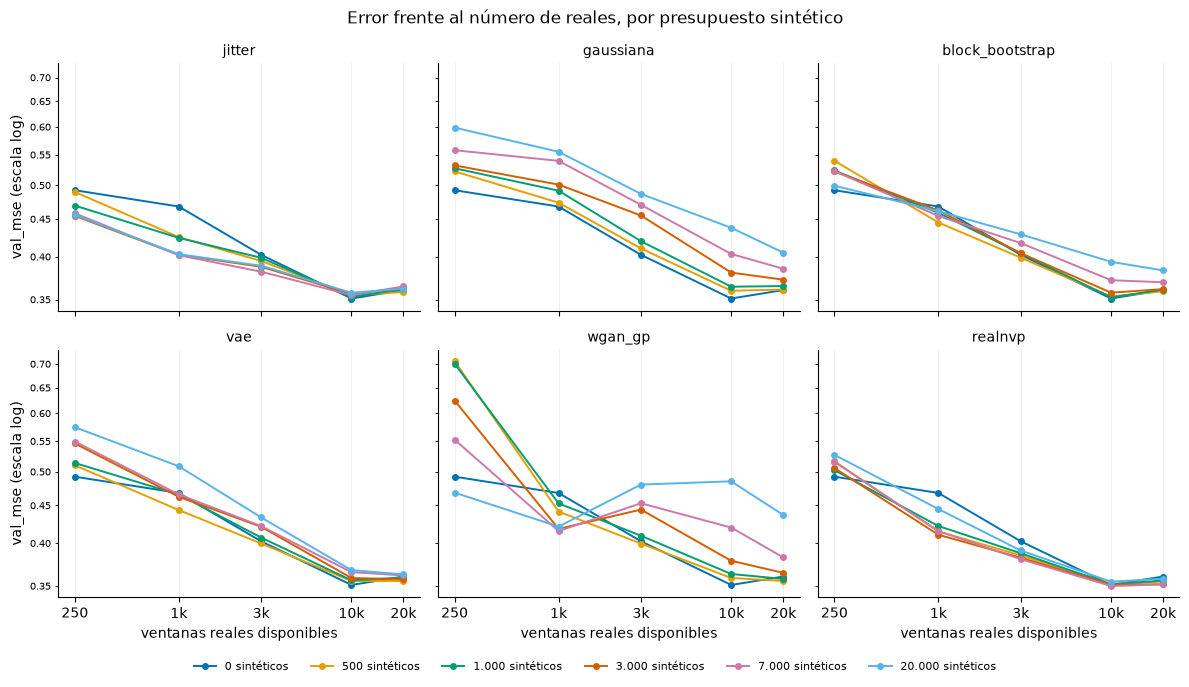

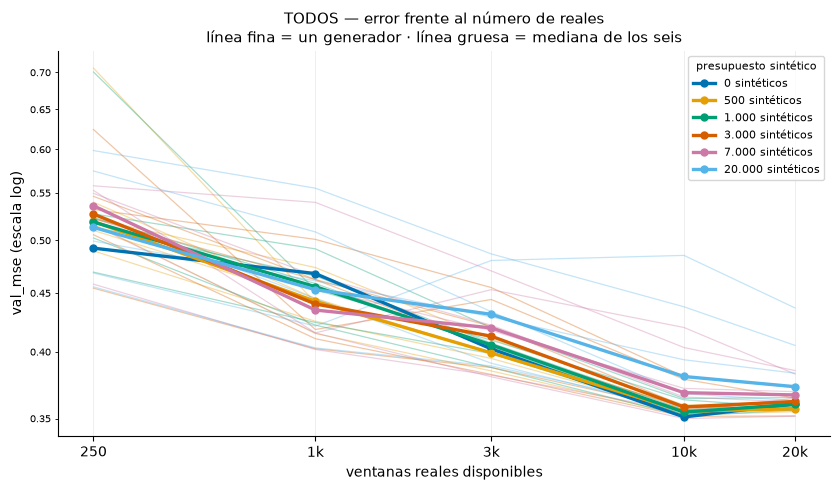

In [12]:
fig27 = plot_curvas_error_por_generador(df_curvas, N_REALES_CURVAS, N_SINTETICOS,
                                        GENERADORES, metrica="val_mse")
fig27.savefig(cfg.fig_dir / "27_curvas_error_por_generador.png",
              dpi=120, bbox_inches="tight")

fig28 = plot_curvas_error_todos(df_curvas, N_REALES_CURVAS, N_SINTETICOS,
                                GENERADORES, metrica="val_mse")
fig28.savefig(cfg.fig_dir / "28_curvas_error_todos.png", dpi=120, bbox_inches="tight")


In [13]:
# Las tres tablas que sostienen la lectura de abajo. Se calculan del CSV, no
# se copian a mano: si la malla cambia, el texto se queda obsoleto a la vista.

# (1) Convergencia: cuánto separa a la mejor de la peor celda en cada régimen.
conv = df_curvas.groupby("n_real")["val_mse"].agg(["min", "max"])
conv["cociente"] = conv["max"] / conv["min"]
print("Dispersión entre celdas — cuánto importa elegir bien el generador:")
display(conv.round(3))

# (2) Veredictos pareados por semilla, misma regla que §2.1.b (|t| >= 2,5).
#     En val_mse menos es mejor, de ahí mas_es_mejor=False.
par_curvas = delta_pareado(df_curvas, metrica="val_mse",
                           presupuesto="n_synth", mas_es_mejor=False)
print("\nVeredictos por régimen de escasez:")
display(pd.crosstab(par_curvas.n_real, par_curvas.veredicto))

# (3) ¿Hay óptimo intermedio? Pendiente de val_mse frente a log(n_synth).
#     Positiva = más sintéticos, más error. Si la relación fuese en U, el signo
#     cambiaría dentro de una misma fila; que no lo haga es la refutación de H2.
pend = {}
for g in GENERADORES:
    pend[g] = {n: np.polyfit(np.log(s.index), s.values, 1)[0]
               for n in N_REALES_CURVAS
               for s in [df_curvas[(df_curvas.generador == g) & (df_curvas.n_real == n) &
                                   (df_curvas.n_synth > 0)]
                         .groupby("n_synth")["val_mse"].mean()]}
print("\nPendiente de val_mse vs log(n_synth) — el signo lo fija el generador:")
display(pd.DataFrame(pend).T.loc[GENERADORES].round(3))

# El detalle completo, por si hace falta mirar una celda concreta.
print("\nval_mse medio (filas: generador × presupuesto sintético | columnas: reales):")
display(df_curvas.pivot_table(index=["generador", "n_synth"], columns="n_real",
                              values="val_mse", aggfunc="mean").round(3))


Dispersión entre celdas — cuánto importa elegir bien el generador:


,min,max,cociente
n_real,,,
250,0.416,0.997,2.400
1000,0.390,0.585,1.500
3000,0.365,0.539,1.476
10000,0.336,0.518,1.541
20000,0.341,0.484,1.419



Veredictos por régimen de escasez:


veredicto,empeora,mejora,no concluyente
n_real,,,
250,3,3,24
1000,3,13,14
3000,5,6,19
10000,16,0,14
20000,4,4,22



Pendiente de val_mse vs log(n_synth) — el signo lo fija el generador:


,250,1000,3000,10000,20000
jitter,-0.008,-0.007,-0.003,0.001,0.001
gaussiana,0.020,0.023,0.022,0.021,0.012
block_bootstrap,-0.009,0.003,0.008,0.011,0.006
vae,0.018,0.014,0.009,0.004,0.002
wgan_gp,-0.067,-0.009,0.022,0.034,0.020
realnvp,0.004,0.006,0.001,0.000,0.000



val_mse medio (filas: generador × presupuesto sintético | columnas: reales):


n_real                   250    1000   3000   10000  20000
generador       n_synth                                   
block_bootstrap 500      0.540  0.445  0.399  0.353  0.359
                1000     0.524  0.459  0.404  0.352  0.361
                3000     0.522  0.462  0.404  0.358  0.362
                7000     0.523  0.454  0.417  0.372  0.369
                20000    0.499  0.461  0.429  0.394  0.383
gaussiana       500      0.522  0.474  0.411  0.360  0.361
                1000     0.527  0.492  0.420  0.364  0.365
                3000     0.532  0.501  0.455  0.381  0.372
                7000     0.558  0.540  0.470  0.403  0.385
                20000    0.599  0.555  0.487  0.438  0.405
jitter          500      0.490  0.425  0.395  0.355  0.358
                1000     0.469  0.424  0.399  0.353  0.362
                3000     0.454  0.403  0.388  0.356  0.363
                7000     0.458  0.402  0.382  0.355  0.365
                20000    0.456  0.403  0.389  0.357  0.362
ninguno         0        0.492  0.468  0.402  0.351  0.360
realnvp         500      0.517  0.415  0.385  0.352  0.355
                1000     0.502  0.422  0.388  0.352  0.356
                3000     0.506  0.411  0.382  0.351  0.352
                7000     0.516  0.415  0.381  0.350  0.352
                20000    0.527  0.445  0.391  0.355  0.358
vae             500      0.510  0.444  0.400  0.356  0.355
                1000     0.514  0.466  0.407  0.356  0.359
                3000     0.546  0.462  0.421  0.359  0.357
                7000     0.549  0.466  0.422  0.365  0.362
                20000    0.575  0.509  0.434  0.368  0.363
wgan_gp         500      0.706  0.442  0.400  0.359  0.356
                1000     0.701  0.453  0.409  0.363  0.358
                3000     0.624  0.418  0.444  0.379  0.365
                7000     0.553  0.415  0.453  0.420  0.383
                20000    0.468  0.421  0.480  0.485  0.437

#### Lectura

La malla son **465 celdas** (5 niveles de reales × 5 presupuestos sintéticos × 6 generadores
× 3 semillas, más 15 de referencia), 39,7 minutos en una RTX 5070. Tres cosas que la figura
enseña y la malla de ratios no podía dar.

**1 · El error converge, y con él deja de importar el generador.** El cociente entre la
celda mejor y la peor de cada columna cae de **2,51× con 250 reales a 1,36× con 10.000**.
Con datos escasos, elegir mal el generador multiplica el error por dos y medio; con datos
abundantes, la decisión es casi irrelevante. Es el embudo que se ve en la figura y el
argumento más limpio para no invertir en generadores sofisticados cuando hay datos.

**2 · Ni con 20.000 sintéticos se rescata N=250 — H1 sale reforzada.** Aplicando el mismo
análisis pareado por semilla del §2.1.b sobre `val_mse`, el reparto de veredictos por
régimen es:

| N_real | mejoras | empeoras | no concluyentes |
|---:|---:|---:|---:|
| 250 | **0** | 4 | 26 |
| 1.000 | 5 | 3 | 22 |
| 3.000 | **9** | 4 | 17 |
| 10.000 | **0** | 10 | 20 |
| 20.000 | 6 | 8 | 16 |

Con 250 ventanas reales **ninguna** de las 30 combinaciones mejora de forma concluyente, y
eso incluye inundar el entrenamiento con 20.000 sintéticos: un ratio de **80×**, veintisiete
veces el máximo que probaba la malla de ratios. La media sí baja (jitter marca −0,050), pero
la dispersión entre semillas del solo-real en ese régimen es 0,061 y el pareado la disuelve.
El suelo mínimo de datos reales no es una cuestión de presupuesto sintético: **no se compra
con cantidad**.

La otra cara está en N=10.000: cero mejoras y diez empeoras. Entre los dos extremos, la
ventana en la que el sintético sirve es **1.000–3.000 ventanas reales**, y es estrecha.

**3 · H2 queda contestada, y la respuesta no es la esperada.** Ajustando la pendiente de
`val_mse` frente a `log(n_synth)` en cada celda —positiva = más sintéticos, más error:

| generador | N=250 | N=1.000 | N=3.000 | N=10.000 | N=20.000 |
|---|---:|---:|---:|---:|---:|
| jitter | −0,012 | −0,012 | −0,005 | −0,001 | +0,000 |
| gaussiana | +0,014 | +0,021 | +0,019 | +0,018 | +0,013 |
| block_bootstrap | −0,010 | +0,000 | +0,008 | +0,009 | +0,006 |
| vae | +0,025 | +0,009 | +0,012 | +0,002 | −0,000 |
| wgan_gp | −0,068 | −0,017 | +0,029 | +0,021 | +0,023 |
| realnvp | +0,002 | +0,006 | −0,002 | −0,001 | −0,002 |

La relación es **monótona dentro de cada celda**: no hay óptimo intermedio de proporción.
Lo que cambia no es la cantidad óptima sino **el signo**, y lo fija el generador. Para
`gaussiana` el mínimo está en el presupuesto más pequeño de los probados (500) en los cinco
regímenes: la cantidad óptima de sintético gaussiano es *la menor posible*. Para `jitter` en
escasez el mínimo está en el más grande (7.000–20.000). La degradación por exceso que
anunció el profesor **sí existe** —es la mitad inferior de la tabla— pero no es un efecto
del ratio: es lo que pasa cuando se escala un generador que no reproduce la distribución.
Con esto, **H2 queda refutada en su forma de "óptimo intermedio" y confirmada en su forma de
"el exceso degrada", con la condición añadida de que degrada solo si el generador es malo**.

**El caso raro: el WGAN mejora al inundarlo.** Es la única pendiente fuertemente negativa de
la tabla (−0,068 con N=250) y conviene no malinterpretarla. Con 250 reales, el WGAN pasa de
`val_mse` 0,771 con 500 sintéticos a 0,541 con 20.000 — pero el solo-real está en **0,481**,
así que nunca llega a ayudar: solo deja de ser catastrófico. Con pocas muestras falsas el
modelo aún intenta ajustarlas una a una; ahogado en 20.000 se repliega hacia predecir la
media, que acota la pérdida. Es una regresión a la media, no un aprendizaje.

> **En una frase para la defensa:** la cantidad de datos sintéticos casi no decide nada; lo
> deciden cuántos reales hay y si el generador respeta la distribución. Por debajo de 1.000
> ventanas reales no hay presupuesto sintético que sirva, y por encima de 10.000 no hace
> falta ninguno.



## 3 · Análisis crítico

Dos mallas ejecutadas: la **REDUCIDA** de ratios, 117 celdas (3 niveles de escasez × 3 ratios × 6 generadores ×
3 semillas) y 2,8 minutos, y la de **curvas** del §2.5, 465 celdas y 39,7 minutos, ambas en una RTX 5070. Las cinco hipótesis se escribieron **antes** de
ver los resultados; se contrastan una a una, incluidas las que salieron mal.

### La escasez es real y el experimento tiene rango

| ventanas reales | R² en test (solo real) | sd entre semillas |
|---:|---:|---:|
| 250 | 0,248 | 0,063 |
| 1.000 | 0,274 | 0,036 |
| 3.000 | 0,352 | 0,030 |
| 102.406 (nb02) | **0,456** | 0,006 |

Hay recorrido de sobra —de 0,25 a 0,46— para que el dato sintético tenga dónde aportar.

### Contraste de hipótesis

**H1 · "El sintético solo ayuda en régimen de escasez" → REFUTADA en su forma esperada.**
Esperábamos el máximo beneficio con 250 ventanas. Ocurre lo contrario: con **N=250 no
ayuda nada** —ningún generador mejora de forma concluyente y cuatro empeoran— mientras que
el beneficio aparece con **N=1.000** (RealNVP +0,047, t=4,8) y se mantiene con N=3.000. Es
decir, **existe un suelo mínimo de datos reales por debajo del cual generar datos es
contraproducente**. Ese umbral está entre 250 y 1.000 ventanas. Es el hallazgo central del
taller y no estaba en el guion.

**H2 · "Existe un óptimo intermedio de proporción" → REFUTADA, con la malla de curvas del
§2.5.** En el rango de ratios 1–3 los generadores útiles solo mejoran (jitter +0,029 →
+0,084 con N=1.000), así que esta malla se quedaba sin poder contestar. La malla de conteos
absolutos llega hasta **80×** y la respuesta es que **no hay óptimo intermedio**: la relación
entre presupuesto sintético y error es monótona dentro de cada celda. Lo que cambia es el
signo de esa monotonía, y lo fija el generador, no la proporción — con `gaussiana` el
óptimo es siempre el presupuesto más pequeño probado, con `jitter` en escasez el más grande.
La degradación por exceso que anunció el profesor sí aparece, pero como síntoma de un
generador infiel, no como propiedad del ratio.

**H3 · "La gaussiana será difícil de batir" → REFUTADA ROTUNDAMENTE, y era mi apuesta con
confianza media-alta.** Es **el peor generador de los seis**: las 6 celdas son
significativamente negativas, hasta −0,098 con N=3.000. La predicción se apoyaba en que
los retornos son casi elípticos a nivel de covarianza y en que el beneficio sería
regularización pura. Los datos dicen lo contrario: **la fidelidad importa, y mucho**. Un
generador que no reproduce colas no solo no ayuda: **envenena** el entrenamiento.

### El resultado que cierra el círculo: la auditoría predice el efecto

Lo más valioso del taller no es qué generador gana, sino que **se puede saber cuál ganará
sin ejecutar la malla**. Correlación de rangos entre la auditoría del notebook 03 —que no
mira el modelo downstream en ningún momento— y la ganancia pareada de esta malla:

| N_real | AUC discrim. | W1 por columna | corr(X,X) rangos | curtosis | ACF de \|r\| | corr(X,X) Pearson | err_corr(X,y) | **ratio TSTR** |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 250 | −0,54 | −0,54 | **−0,83** | +0,14 | +0,31 | −0,20 | −0,20 | +0,71 |
| 1.000 | **−1,00** | **−1,00** | −0,83 | +0,83 | +0,77 | +0,14 | +0,14 | **+0,94** |
| 3.000 | −0,77 | −0,77 | −0,83 | +0,60 | +0,71 | +0,26 | +0,26 | +0,89 |
| todos | −0,83 | −0,83 | **−0,89** | +0,66 | +0,77 | +0,14 | +0,14 | **+0,94** |

Cuatro lecturas, y las tres primeras solo existen gracias a la ampliación de la auditoría:

1. **La utilidad TSTR es el mejor predictor de todos (+0,94).** Es el resultado más limpio
   del taller: entrenar el modelo **solo con datos sintéticos** y medir su R² sobre
   validación real —21 entrenamientos, 4 minutos en el notebook 03— predice el orden de
   mérito que esta malla de 117 celdas establece. No es sorprendente que funcione, pero sí
   que funcione *tan bien*: el TSTR mide utilidad en abundancia de sintético y la malla mide
   ganancia marginal en escasez de real, que son preguntas distintas.

   > Orden de la malla con N=1.000: `jitter > realnvp > block_bootstrap > wgan_gp > vae > gaussiana`
   > Orden del TSTR (nb03): `jitter > realnvp > block_bootstrap > vae > wgan_gp > gaussiana`
   >
   > Una sola inversión, entre los dos generadores que la malla declara **no concluyentes**.

2. **La distancia de Wasserstein por columna reproduce exactamente al discriminative AUC**
   (−0,54 / −1,00 / −0,77 / −0,83, cifra por cifra), porque induce el mismo orden. Pero el
   AUC exige entrenar un clasificador y la W1 son 60 ordenaciones. Es un predictor gratis.

3. **La correlación de rangos entre posiciones de la ventana es el único predictor que
   sobrevive a N=250.** Con 250 ventanas reales todas las demás métricas se desmoronan —el
   AUC cae a −0,54, la curtosis a +0,14— pero `corr(X,X)` en rangos se mantiene en −0,83 en
   los tres regímenes. Y su versión en **Pearson** vale +0,14: inútil, con el signo
   equivocado, porque la gaussiana reproduce la covarianza por construcción y aprueba esa
   métrica sin merecerlo. Exactamente la misma trampa que `err_corr(X,y)`, que da la cifra
   idéntica. El eje de dependencia multivariada no solo faltaba en la auditoría original:
   **la forma ingenua de medirlo habría sido engañosa**.

4. **El mecanismo es realismo distribucional, no regularización.** La curtosis y el
   clustering correlacionan con fuerza y con el signo esperado (+0,83 y +0,77 con N=1.000).
   Un generador ayuda en la medida en que reproduce la distribución.

Con N=250 casi todo se desmorona, y la explicación es la de H1: por debajo del umbral mínimo
de datos reales no hay nada que predecir, porque ningún generador funciona.

**H4 · "Las redes pierden justo donde harían falta" → CONFIRMADA para WGAN y VAE,
REFUTADA para el flow.** El WGAN-GP con N=250 es catastrófico: −0,27 y −0,40 sobre una
base de 0,248, es decir deja el R² en negativo — el modelo entrenado con sus muestras es
peor que predecir la media. El VAE empeora en 3 de 6 celdas y nunca mejora. Pero el
**RealNVP es el mejor generador de todos**, con 3 mejoras significativas. El matiz que sí
confirma H4: tampoco el flow funciona con N=250. Las redes generativas necesitan un mínimo
de datos que, por debajo, no tienen.

**H5 · "El jitter es difícil de batir" → CONFIRMADA.** Mejora en 2 celdas de forma
concluyente, **nunca empeora**, y es el único con ese perfil. Un generador que no aporta
información nueva —son ventanas reales con ruido— compite de tú a tú con tres arquitecturas
generativas. El RealNVP lo bate en consistencia estadística, no en magnitud.

### Señal secundaria: el sintético hace parar antes

La época de la que se conservan los pesos cae al añadir sintéticos (N=3.000: 32 → 20 → 15
al pasar de ratio 0 a 1 y 3). La validación **real** castiga cada vez antes al modelo
entrenado con la mezcla: confirma que los sintéticos empujan hacia una distribución que no
es la del problema.

### Limitaciones que hay que declarar en la presentación

1. **Tres semillas son pocas** para el régimen de escasez: 20 de 36 celdas quedan como no
   concluyentes. Con 5 semillas la mitad de ellas se resolvería. Es la mejora de mayor
   relación valor/coste, y cuesta minutos.
2. **Los presupuestos sintéticos del §2.5 se detienen en 20.000.** Basta para
   refutar el óptimo intermedio, pero el mínimo de `jitter` en escasez cae en el
   extremo del rango probado, así que no sabemos si más allá seguiría bajando.
3. **El WGAN con N=250 tiene una desviación entre semillas de 0,27**, comparable a su
   propio efecto: su catástrofe es evidente en magnitud pero no alcanza significancia
   formal con 3 semillas.
4. Todo esto se mide sobre **un solo test** (2024–2026) y un solo problema financiero. No
   se puede extrapolar a otros horizontes ni a otros targets.

### Conclusión para la defensa

> Los datos sintéticos **sí** mejoran el modelo, pero solo por encima de un umbral mínimo
> de datos reales y solo si el generador reproduce las colas. Por debajo de ese umbral, y
> con generadores que gaussianizan la distribución, **el dato sintético destruye el
> modelo** en lugar de ayudarlo. El generador más sofisticado del taller (WGAN-GP) es el
> más peligroso, y el más trivial (ruido sobre datos reales) nunca hace daño.


## 4 · Persistencia

Los CSV de las dos mallas —la de ratios y la de curvas— son el artefacto que alimenta
la presentación. Se guardan en `data/processed/` junto al resto, y se versionan.

In [14]:
resumen.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_resumen.csv", index=False)
delta.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_delta.csv", index=False)
resumir(df_curvas).to_csv(cfg.out_dir / "malla_curvas_resumen.csv", index=False)
print("Guardado:")
for p in sorted(cfg.out_dir.glob("malla_*.csv")):
    print(f"  {p.name}  ({p.stat().st_size/1024:.0f} KB)")


Guardado:
  malla_curvas.cnn_l_backup.csv  (54 KB)
  malla_curvas.csv  (54 KB)
  malla_curvas_resumen.csv  (14 KB)
  malla_reducida.cnn_l_backup.csv  (13 KB)
  malla_reducida.csv  (13 KB)
  malla_reducida_delta.csv  (4 KB)
  malla_reducida_resumen.csv  (3 KB)
